In [1]:
# =============================================================================
# Part 1: 数据准备 
# =============================================================================
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import os

# --- 1. 加载原始数据 --
S = np.load('results_32x32_gpu.npy')
# S 的形状是 (H, W, Nt, B)，即 (高度, 宽度, 时间步数, 样本数)
H, W, Nt, B = S.shape 
print(f"原始数据形状: 长度={H}, 宽度={W}, 时间步={Nt}, 模拟样本数={B}")
total_time = 3.0

# --- 2. 按指定的 100 / 25 / 25 数量划分模拟样本 ---

# 定义划分数量
train_count = 100
val_count = 25
sim_indices = np.arange(B)
# 获取划分后的模拟样本索引
train_sim_indices = sim_indices[:train_count]
val_sim_indices = sim_indices[train_count : train_count + val_count]
test_sim_indices = sim_indices[train_count + val_count:]

# 根据索引创建数据子集
S_train = S[:, :, :, train_sim_indices]
S_val = S[:, :, :, val_sim_indices]
S_test = S[:, :, :, test_sim_indices]

print(f"模拟样本划分: {len(train_sim_indices)} (训练) / {len(val_sim_indices)} (验证) / {len(test_sim_indices)} (测试)")


# --- 3. 为【训练集】准备张量  ---
print("\n--- 正在处理训练集... ---")
H, W, Nt, B_train = S_train.shape
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)
Y_data_train = S_train[:, :, 1:, :]
initial_conditions_train = S_train[:, :, 0:1, :]
X_data_u0_train = np.repeat(initial_conditions_train, Nt - 1, axis=2)
target_times = time_points[1:]
time_channel_template = target_times.reshape(1, 1, -1, 1)
X_data_time_train = np.broadcast_to(time_channel_template, (H, W, Nt - 1, B_train))
X_data_combined_train = np.stack([X_data_u0_train, X_data_time_train], axis=-1)
X_reshaped_train = X_data_combined_train.transpose(0, 1, 3, 2, 4).reshape(H, W, -1, 2)
Y_reshaped_train = Y_data_train.transpose(0, 1, 3, 2).reshape(H, W, -1)
X_train_final = np.transpose(X_reshaped_train, (2, 3, 0, 1))
Y_train_final = np.expand_dims(np.transpose(Y_reshaped_train, (2, 0, 1)), axis=1)
X_train, Y_train = torch.from_numpy(X_train_final), torch.from_numpy(Y_train_final).float()
print(f"训练集最终形状: X={X_train.shape}, Y={Y_train.shape}")


# --- 4. 为【验证集】准备张量  ---
print("\n--- 正在处理验证集... ---")
H, W, Nt, B_val = S_val.shape
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)
Y_data_val = S_val[:, :, 1:, :]
initial_conditions_val = S_val[:, :, 0:1, :]
X_data_u0_val = np.repeat(initial_conditions_val, Nt - 1, axis=2)
target_times = time_points[1:]
time_channel_template = target_times.reshape(1, 1, -1, 1)
X_data_time_val = np.broadcast_to(time_channel_template, (H, W, Nt - 1, B_val))
X_data_combined_val = np.stack([X_data_u0_val, X_data_time_val], axis=-1)
X_reshaped_val = X_data_combined_val.transpose(0, 1, 3, 2, 4).reshape(H, W, -1, 2)
Y_reshaped_val = Y_data_val.transpose(0, 1, 3, 2).reshape(H, W, -1)
X_val_final = np.transpose(X_reshaped_val, (2, 3, 0, 1))
Y_val_final = np.expand_dims(np.transpose(Y_reshaped_val, (2, 0, 1)), axis=1)
X_val, Y_val = torch.from_numpy(X_val_final), torch.from_numpy(Y_val_final).float()
print(f"验证集最终形状: X={X_val.shape}, Y={Y_val.shape}")


# --- 5. 为【测试集】准备张量  ---
print("\n--- 正在处理测试集... ---")
H, W, Nt, B_test = S_test.shape
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)
Y_data_test = S_test[:, :, 1:, :]
initial_conditions_test = S_test[:, :, 0:1, :]
X_data_u0_test = np.repeat(initial_conditions_test, Nt - 1, axis=2)
target_times = time_points[1:]
time_channel_template = target_times.reshape(1, 1, -1, 1)
X_data_time_test = np.broadcast_to(time_channel_template, (H, W, Nt - 1, B_test))
X_data_combined_test = np.stack([X_data_u0_test, X_data_time_test], axis=-1)
X_reshaped_test = X_data_combined_test.transpose(0, 1, 3, 2, 4).reshape(H, W, -1, 2)
Y_reshaped_test = Y_data_test.transpose(0, 1, 3, 2).reshape(H, W, -1)
X_test_final = np.transpose(X_reshaped_test, (2, 3, 0, 1))
Y_test_final = np.expand_dims(np.transpose(Y_reshaped_test, (2, 0, 1)), axis=1)
X_test, Y_test = torch.from_numpy(X_test_final), torch.from_numpy(Y_test_final).float()
print(f"测试集最终形状: X={X_test.shape}, Y={Y_test.shape}")


# --- 6. 创建最终的 Dataset 和 DataLoader ---
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)
test_dataset = TensorDataset(X_test, Y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



原始数据形状: 长度=32, 宽度=32, 时间步=301, 模拟样本数=150
模拟样本划分: 100 (训练) / 25 (验证) / 25 (测试)

--- 正在处理训练集... ---
训练集最终形状: X=torch.Size([30000, 2, 32, 32]), Y=torch.Size([30000, 1, 32, 32])

--- 正在处理验证集... ---
验证集最终形状: X=torch.Size([7500, 2, 32, 32]), Y=torch.Size([7500, 1, 32, 32])

--- 正在处理测试集... ---
测试集最终形状: X=torch.Size([7500, 2, 32, 32]), Y=torch.Size([7500, 1, 32, 32])


--- 正在计算硬约束边界蒙版 (Hard Constraint Boundary Mask) ---
边界蒙版计算完成。


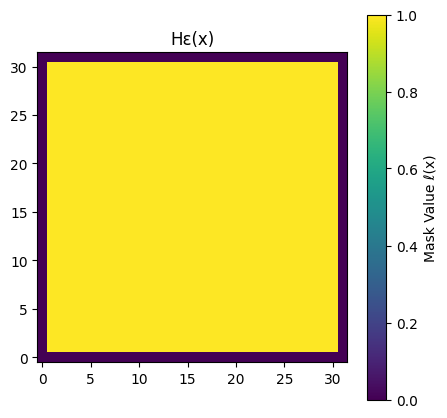

In [2]:
# =============================================================================
# Part 2: 模型定义与训练 
# =============================================================================
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
from neuralop.models import FNO
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy.ndimage import distance_transform_edt 
import time

# --- 1. 定义基础模型  ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = FNO(
    n_modes=(16, 16),
    hidden_channels=64,
    in_channels=2,
    out_channels=1
).to(device)

# --- 2. 计算并准备硬约束边界蒙版 ---
print("--- 正在计算硬约束边界蒙版 (Hard Constraint Boundary Mask) ---")
# a. 从DataLoader中获取数据的空间维度 (H, W)，确保一致性
sample_x, _ = train_dataset[0]
_, H, W = sample_x.shape
epsilon = 1.0 / H  # 设定边界过渡区的厚度 (例如，1个像素的宽度)

# b. 创建一个内部为1，边界为0的网格，用于计算到边界的距离
grid = np.ones((H, W), dtype=np.float32)
grid[0, :] = grid[-1, :] = grid[:, 0] = grid[:, -1] = 0

# c. 使用scipy的高效函数计算每个内部点到最近边界的欧氏距离 d(x)
dist_to_boundary = distance_transform_edt(grid)

# d. 归一化距离，使其与epsilon的尺度匹配
dist_to_boundary /= H

# e. 应用平滑的Heaviside函数，生成蒙版
#    在过渡区内 (d(x) < ε)，使用平滑函数从0过渡到1
#    在内部区域 (d(x) >= ε)，值恒为1
boundary_mask_np = np.where(
    dist_to_boundary < epsilon,
    0.5 * (1 - np.cos(dist_to_boundary * np.pi / epsilon)),
    1.0
).astype(np.float32)

# f. 将Numpy蒙版转换为PyTorch张量，并增加批次和通道维度 -> (1, 1, H, W)
#    然后将其发送到与模型相同的设备上，准备在循环中使用。
H_epsilon_tensor = torch.from_numpy(boundary_mask_np).unsqueeze(0).unsqueeze(0).to(device)
print("边界蒙版计算完成。")

#  可视化检查生成的蒙版
plt.figure(figsize=(5,5))
plt.imshow(H_epsilon_tensor.cpu().squeeze().numpy(), origin='lower', cmap='viridis')
plt.colorbar(label="Mask Value ℓ(x)")
plt.title("Hε(x)")
plt.show()



--- 开始训练带硬约束的 FNO 模型，设备: cuda ---
Epoch 1/100, 训练损失:0.0012253742756513839, 验证损失: 3.7296943011084696e-05
 -> 验证损失降低，模型已保存。
Epoch 2/100, 训练损失:2.1289763848518463e-05, 验证损失: 3.990863971489874e-05
 -> 验证损失未提升。连续未提升次数: 1/7
Epoch 3/100, 训练损失:1.5903039371814863e-05, 验证损失: 8.256099943275207e-06
 -> 验证损失降低，模型已保存。
Epoch 4/100, 训练损失:9.467275252379794e-06, 验证损失: 8.242681555187165e-06
 -> 验证损失降低，模型已保存。
Epoch 5/100, 训练损失:6.547307049074115e-06, 验证损失: 1.2916001643612094e-05
 -> 验证损失未提升。连续未提升次数: 1/7
Epoch 6/100, 训练损失:8.399640564326732e-06, 验证损失: 3.5267243305752036e-06
 -> 验证损失降低，模型已保存。
Epoch 7/100, 训练损失:9.229556190208751e-06, 验证损失: 2.8504072227664344e-06
 -> 验证损失降低，模型已保存。
Epoch 8/100, 训练损失:2.6629640557349047e-06, 验证损失: 2.475874780102304e-06
 -> 验证损失降低，模型已保存。
Epoch 9/100, 训练损失:5.796938554051214e-06, 验证损失: 2.4664269944223324e-06
 -> 验证损失降低，模型已保存。
Epoch 10/100, 训练损失:4.756456179347297e-06, 验证损失: 3.1250632778634193e-06
 -> 验证损失未提升。连续未提升次数: 1/7
Epoch 11/100, 训练损失:4.36694002251531e-06, 验证损失: 2.420001542555313

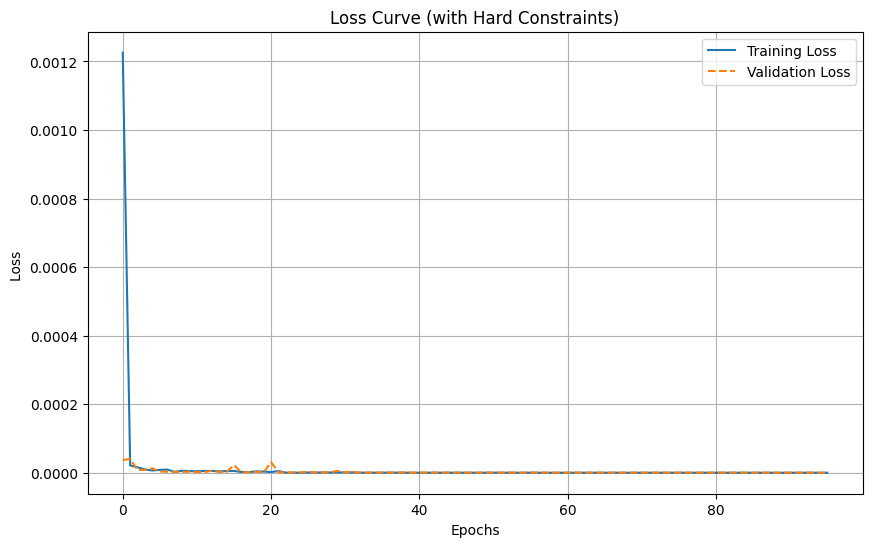

In [3]:
# --- 3. 定义损失、优化器等 ---
loss_mse = torch.nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=4) 
epochs = 100      
patience = 7  
epochs_no_improve = 0
train_losses, val_losses = [], []
best_val_loss = float('inf')

output_dir = 'model_32x32_16_h'
if not os.path.exists(output_dir): os.makedirs(output_dir)
full_save_path = os.path.join(output_dir, 'best_fno_model_hard.pth')


# --- 4. 训练循环  ---
print(f"\n--- 开始训练带硬约束的 FNO 模型，设备: {device} ---")
start_time = time.time()
for epoch in range(epochs):
    model.train()
    current_train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        # 1. 获取基础模型的"自由"输出
        free_output = model(x)
        
        # 2. 应用硬约束蒙版
        #    利用PyTorch的广播机制，(1,1,H,W)的蒙版会自动与(B,1,H,W)的输出相乘
        constrained_output = H_epsilon_tensor * free_output
        
        # 3. 使用被约束过的、保证边界为0的输出去计算损失
        loss = loss_mse(constrained_output.squeeze(), y.squeeze())
        
        loss.backward()
        optimizer.step()
        current_train_loss += loss.item()
    
    avg_train_loss = current_train_loss / len(train_loader)
    train_losses.append(avg_train_loss) 

    # --- 验证阶段 ---
    model.eval()
    current_val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            free_output = model(x)
            constrained_output = H_epsilon_tensor * free_output
            
            loss = loss_mse(constrained_output.squeeze(), y.squeeze())
            current_val_loss += loss.item()
            
    avg_val_loss = current_val_loss / len(val_loader)

    scheduler.step(avg_val_loss)
    val_losses.append(avg_val_loss) 

    print(f"Epoch {epoch+1}/{epochs}, 训练损失:{avg_train_loss}, 验证损失: {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), full_save_path)
        print(f" -> 验证损失降低，模型已保存。")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f" -> 验证损失未提升。连续未提升次数: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print(f"\n验证损失连续 {patience} 个epoch未提升，触发早停！")
        break
end_time = time.time()
print("训练完成！")

# --- 5. 绘制并保存损失曲线 (保持不变) ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.title('Loss Curve (with Hard Constraints)')
plt.xlabel('Epochs')
plt.ylabel('Loss ')
plt.legend()
plt.grid(True)
figure_save_path = os.path.join(output_dir, 'loss_curve_hard_constraint.png')
plt.savefig(figure_save_path)
print(f"损失曲线图已保存至: {figure_save_path}")
plt.show()

In [4]:
# --- 计算并打印训练耗时 ---
total_training_seconds = end_time - start_time
total_training_minutes = total_training_seconds / 60
print(f"\n总训练耗时: {total_training_seconds:.2f} 秒 ({total_training_minutes:.2f} 分钟)")


总训练耗时: 656.16 秒 (10.94 分钟)


/tmp/ipykernel_1275/2172584139.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


成功加载带硬约束的模型: model_32x32_16_h/best_fno_model_hard.pth
评估用的边界蒙版已准备就绪。

--- 正在测试集上进行量化评估... ---
在整个测试集上的平均 MSE 损失 (应用硬约束后): 0.00000014

--- 开始对测试样本 130 进行带硬约束的直接预测可视化 ---

已确定全局色条范围: Vmin=0.0000, Vmax=0.2435
已确定全局误差色条范围: Vmax_error=0.0031

--- 正在绘制时刻 t = 0.1000s 的图像 ---
  平均绝对误差: 0.000322
  最大绝对误差: 0.003119


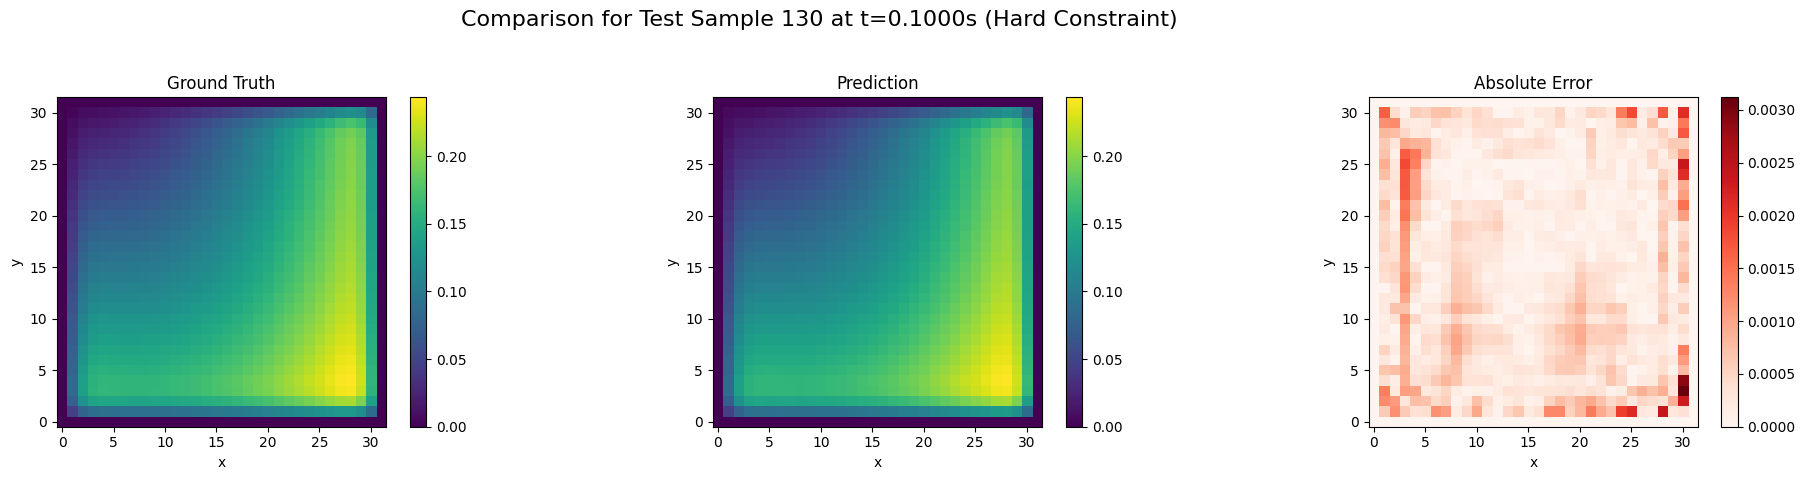

--- 正在绘制时刻 t = 1.0000s 的图像 ---
  平均绝对误差: 0.000287
  最大绝对误差: 0.001070


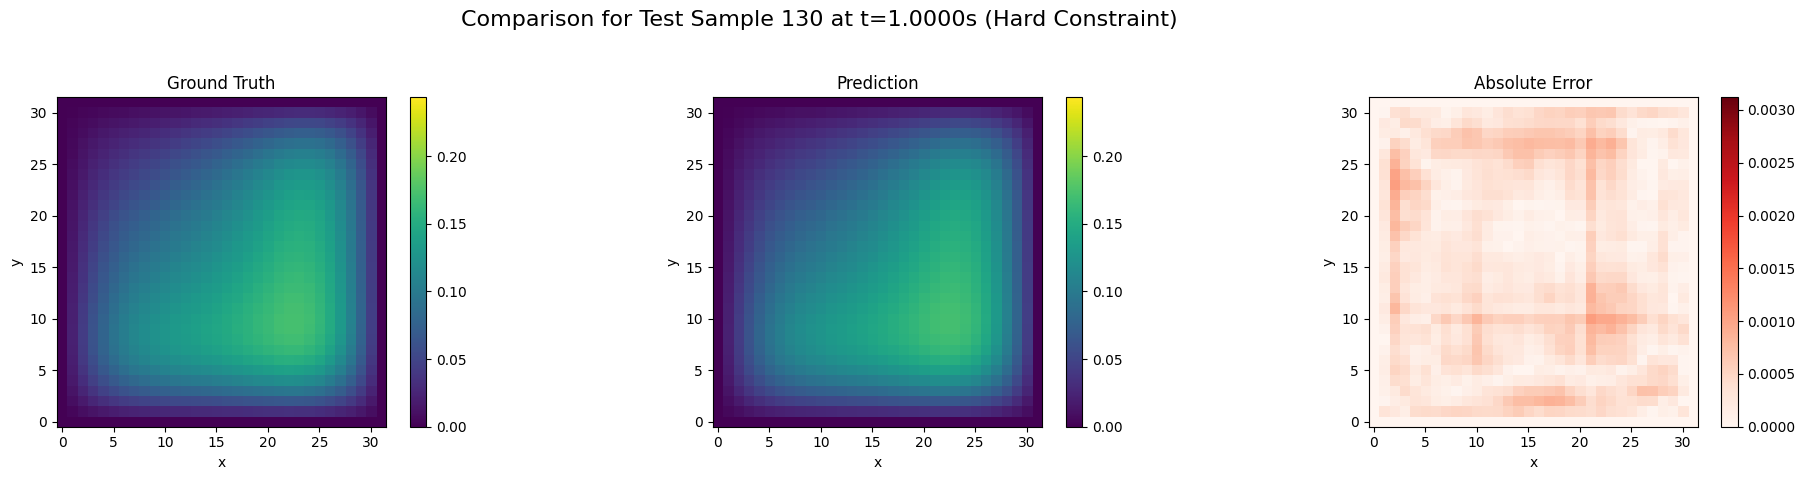

--- 正在绘制时刻 t = 2.0000s 的图像 ---
  平均绝对误差: 0.000194
  最大绝对误差: 0.000835


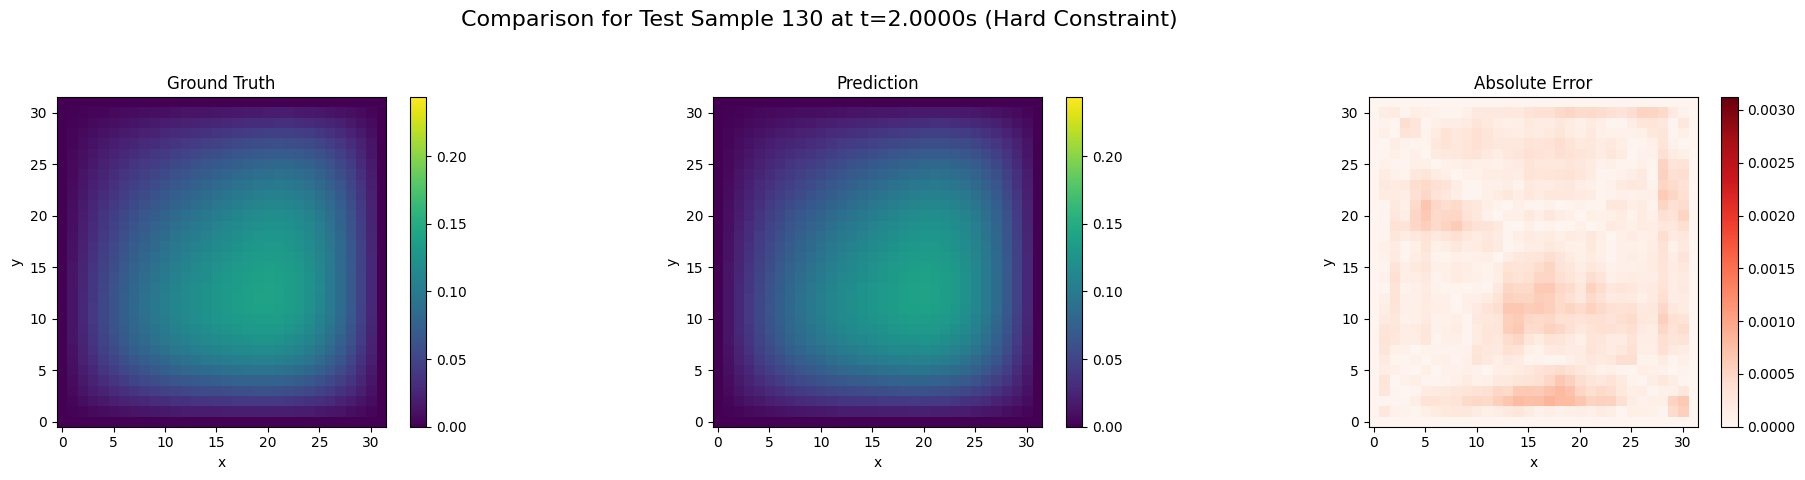

--- 正在绘制时刻 t = 3.0000s 的图像 ---
  平均绝对误差: 0.000200
  最大绝对误差: 0.000831


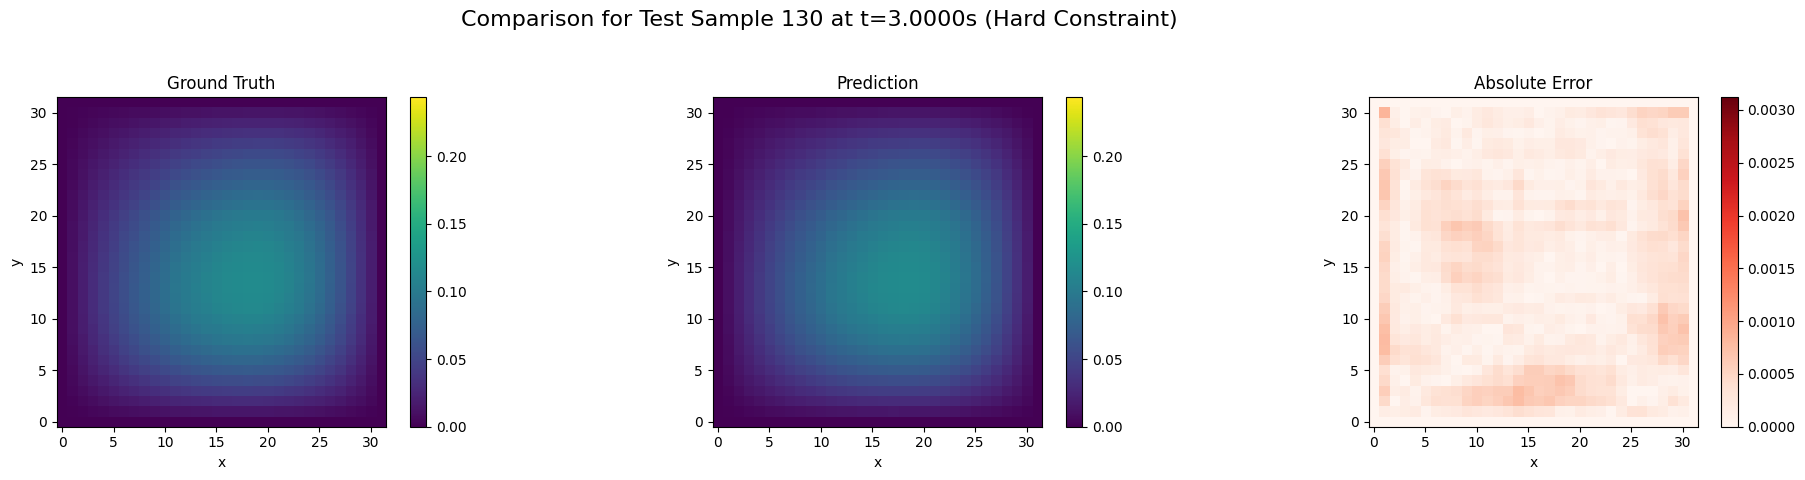

In [2]:
# =============================================================================
# Part 3: 模型评估与可视化 
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from neuralop.models import FNO
from scipy.ndimage import distance_transform_edt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 1. 加载带硬约束的模型和边界蒙版 ---
model = FNO(n_modes=(16, 16), hidden_channels=64, in_channels=2, out_channels=1)
model_path = 'model_32x32_16_h/best_fno_model_hard.pth'

if not os.path.exists(model_path):
    print(f"错误: 找不到模型文件 {model_path}。请先运行带硬约束的训练代码。")
    exit()
else:
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"成功加载带硬约束的模型: {model_path}")

# 加载或重新计算评估时所需的边界蒙版
H, W = 32, 32
epsilon = 1.0 / H
grid = np.ones((H, W), dtype=np.float32)
grid[0, :] = grid[-1, :] = grid[:, 0] = grid[:, -1] = 0
dist_to_boundary = distance_transform_edt(grid) / H
boundary_mask_np = np.where(
    dist_to_boundary < epsilon,
    0.5 * (1 - np.cos(dist_to_boundary * np.pi / epsilon)),
    1.0
).astype(np.float32)
H_epsilon_tensor = torch.from_numpy(boundary_mask_np).unsqueeze(0).unsqueeze(0).to(device)
print("评估用的边界蒙版已准备就绪。")


# --- 2. 在【整个测试集】上进行量化评估  ---
print("\n--- 正在测试集上进行量化评估... ---")
loss_mse = torch.nn.MSELoss()
test_loss = 0.0
# 假设 test_loader 已经从 Part 1 创建并加载
try:
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            # 得到模型的"自由"预测
            free_out = model(x)
            # 在计算损失前，应用硬约束
            constrained_out = H_epsilon_tensor * free_out
            # 基于约束后的结果计算损失
            loss = loss_mse(constrained_out, y)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    print(f"在整个测试集上的平均 MSE 损失 (应用硬约束后): {avg_test_loss:.8f}")
except NameError:
    print("错误: 变量 'test_loader' 未定义。请确保您已经运行了 Part 1 的数据准备代码。")


# --- 3. 在【测试集的单个样本】上进行可视化分析 ---
# 定义与 Part 1 中一致的划分
train_count = 100
val_count = 25
test_start_index = train_count + val_count

# 加载原始数据
S = np.load('results_32x32_gpu.npy')
H, W, Nt, B = S.shape
total_time = 3.0
time_points = np.linspace(0, total_time, Nt, dtype=np.float32)

# 定义辅助函数
def predict_at_time_constrained(model, initial_condition_np, target_time, constraint_mask):
    model.eval()
    with torch.no_grad():
        u0_tensor = torch.from_numpy(initial_condition_np).float().unsqueeze(0).unsqueeze(0).to(device)
        H, W = initial_condition_np.shape
        time_tensor = torch.full((1, 1, H, W), float(target_time), device=device)
        model_input = torch.cat([u0_tensor, time_tensor], dim=1)
        free_prediction = model(model_input)
        constrained_prediction = constraint_mask * free_prediction
        return constrained_prediction.squeeze().cpu().numpy()

def calculate_errors(prediction, ground_truth):
    if isinstance(prediction, np.ndarray): prediction = torch.from_numpy(prediction)
    if isinstance(ground_truth, np.ndarray): ground_truth = torch.from_numpy(ground_truth)
    abs_error = torch.abs(prediction - ground_truth)
    return {
        "mean_absolute": torch.mean(abs_error).item(),
        "max_absolute": torch.max(abs_error).item(),
        "abs_error_map": abs_error.numpy()
    }

def plot_comparison_unified_cmap(ground_truth, prediction, abs_error_map, time_val, sample_idx, vmin, vmax, error_vmax):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Comparison for Test Sample {sample_idx} at t={time_val:.4f}s (Hard Constraint)', fontsize=16)
    im1 = axes[0].imshow(ground_truth, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    axes[0].set_title(f'Ground Truth'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    im2 = axes[1].imshow(prediction, vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    axes[1].set_title(f'Prediction'); axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    im3 = axes[2].imshow(abs_error_map, vmin=0, vmax=error_vmax, origin='lower', cmap='Reds')
    axes[2].set_title(f'Absolute Error'); axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()


# --- 主执行流程 ---
# 选择一个测试集中的样本进行分析
sample_offset = 5 # 您可以修改这个值 (例如从 0 到 B-125-1)
sample_index_in_S = test_start_index + sample_offset

initial_condition = S[:, :, 0, sample_index_in_S]
ground_truth_series = S[:, :, :, sample_index_in_S]

times_to_analyze = [0.1, 1.0, 2.0, 3.0]

print(f"\n--- 开始对测试样本 {sample_index_in_S} 进行带硬约束的直接预测可视化 ---")

# 步骤 1: 预计算所有预测和误差，以确定全局色条范围
all_predictions, all_gt_slices, all_error_maps = [], [], []
for t_val in times_to_analyze:
    predicted_slice = predict_at_time_constrained(model, initial_condition, t_val, H_epsilon_tensor)
    time_idx = np.argmin(np.abs(time_points - t_val))
    gt_slice = ground_truth_series[:, :, time_idx]
    error_dict = calculate_errors(predicted_slice, gt_slice)
    all_predictions.append(predicted_slice)
    all_gt_slices.append(gt_slice)
    all_error_maps.append(error_dict['abs_error_map'])

all_predictions_np = np.stack(all_predictions)
all_gt_slices_np = np.stack(all_gt_slices)
all_error_maps_np = np.stack(all_error_maps)
global_vmin = min(all_predictions_np.min(), all_gt_slices_np.min())
global_vmax = max(all_predictions_np.max(), all_gt_slices_np.max())
global_error_vmax = all_error_maps_np.max()

print(f"\n已确定全局色条范围: Vmin={global_vmin:.4f}, Vmax={global_vmax:.4f}")
print(f"已确定全局误差色条范围: Vmax_error={global_error_vmax:.4f}\n")

# 步骤 2: 使用确定的全局色条范围来循环绘图
for i, t_val in enumerate(times_to_analyze):
    print(f"--- 正在绘制时刻 t = {t_val:.4f}s 的图像 ---")
    predicted_slice, gt_slice, error_map = all_predictions[i], all_gt_slices[i], all_error_maps[i]
    mean_abs_err, max_abs_err = np.mean(error_map), np.max(error_map)
    print(f"  平均绝对误差: {mean_abs_err:.6f}")
    print(f"  最大绝对误差: {max_abs_err:.6f}")
    plot_comparison_unified_cmap(
        gt_slice, predicted_slice, error_map, t_val, sample_index_in_S,
        vmin=global_vmin, vmax=global_vmax, error_vmax=global_error_vmax
    )